In [1]:
"""
    same plot as 4_fp_baseline
    but with 4 bit 
"""

# Autoreload
%load_ext autoreload
%autoreload 2

import gc
import ctypes
import csv
import json
import random
import subprocess
import sys
from pathlib import Path
from dataclasses import dataclass

import requests
from PIL import Image
import datasets
import numpy as np
import torch
from io import BytesIO
from matplotlib import pyplot as plt
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2VLForConditionalGeneration


FIXED_RESOLUTION = 448  # → 16×16 merged token grid (256 visual tokens)
seed = 42
_HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"}
VISUAL_LAYERS = [1, 2, 4, 8, 16, 24, 26, 27]  # matches latentlens-qwen2vl-embeddings index layers


def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def gc_cuda():
    """Gargage collect RAM & Torch (CUDA) memory."""
    gc.collect()
    if torch.cuda.is_available():
        ctypes.CDLL("libc.so.6").malloc_trim(0)
        torch.cuda.empty_cache()

seed = 42
seed_all(seed)

def _ensure_nlp_resources():
    print("\nChecking NLP resources...")
    import nltk
    try:
        wn = __import__("nltk.corpus", fromlist=["wordnet"]).wordnet
        wn.synsets("dog")
    except Exception:
        print("  Downloading NLTK wordnet + omw-1.4...")
        nltk.download("wordnet", quiet=True)
        nltk.download("omw-1.4", quiet=True)

    try:
        import spacy
        spacy.load("en_core_web_sm")
    except OSError:
        print("  Downloading spaCy en_core_web_sm...")
        subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)

    print("  NLP resources OK")

_ensure_nlp_resources()



Checking NLP resources...
  NLP resources OK


In [2]:
# load val set, fp16 patch assignments, index, model

model_dir = Path("/workspace/latentlens/experiment/data/Qwen2-VL-7B-Instruct")
index_dir = Path("/workspace/latentlens/experiment/data/latentlens-qwen2vl-embeddings")
data_dir = Path("/workspace/latentlens/experiment/data/pixmo_cap_val100")
patch_assignments_path = Path(
    "/workspace/latentlens/experiment/data/results/patch_assignments.parquet"
)

# not used for sampling here
def load_data():
    ds_val100 = datasets.load_dataset(
        "parquet",
        data_files={"validation": str(data_dir / "data" / "validation-*.parquet")},
    )["validation"]

    print(f"Examples : {len(ds_val100)}")
    print(f"Columns  : {ds_val100.column_names}")
    return ds_val100


def load_patch_assignments(path: Path) -> datasets.Dataset:
    """Load fp16 baseline patch coords saved by 4_fp_baseline.ipynb."""
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run notebook 4 and save patch_assignments.parquet first."
        )

    ds = datasets.load_dataset("parquet", data_files=str(path), split="train")
    expected_cols = {
        "val_idx",
        "layer",
        "patch_row",
        "patch_col",
        "center_row",
        "center_col",
        "patch_token_idx",
    }
    missing = expected_cols - set(ds.column_names)
    if missing:
        raise ValueError(f"patch_assignments missing columns: {sorted(missing)}")

    print(f"\nPatch assignments : {len(ds)} rows")
    print(f"Columns           : {ds.column_names}")
    print(f"Layers            : {sorted(set(ds['layer']))}")
    print(f"Images (val_idx)  : {len(set(ds['val_idx']))}")
    return ds

@dataclass
class Bank:
    embeddings: torch.Tensor   # [N, hidden_dim] float16, kept on CPU
    metadata: list             # [{token_str, token_id, caption, position}, ...]


def load_banks(index_dir: Path, layers: list = None) -> dict:
    """Load reference embedding banks. Returns {layer: Bank}.
    If layers is None, loads all available layer_* directories."""
    if layers is None:
        layers = sorted(
            int(p.name.split("_")[1])
            for p in index_dir.iterdir()
            if p.is_dir() and p.name.startswith("layer_")
        )

    banks = {}
    for L in layers:
        path = index_dir / f"layer_{L}" / "embeddings_cache.pt"
        print(f"  Loading layer {L} from {path.name}...", end=" ", flush=True)
        data = torch.load(path, map_location="cpu", weights_only=False)
        banks[L] = Bank(embeddings=data["embeddings"], metadata=data["metadata"])
        e = data["embeddings"]
        print(f"shape={list(e.shape)} dtype={e.dtype}")

    return banks

def load_model(model_dir: Path):
    """Load Qwen2-VL-7B with bitsandbytes 4-bit NF4 LLM quantization.
    Vision tower + merger + lm_head stay in fp16 (per experiment spec).
    Requires ~4.5 GB VRAM with current GPU.
    """
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,
        llm_int8_skip_modules=["visual", "lm_head"],
    )
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        str(model_dir),
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
        attn_implementation="flash_attention_2",
    )
    model.eval()
    processor = AutoProcessor.from_pretrained(str(model_dir))
    px = FIXED_RESOLUTION * FIXED_RESOLUTION
    processor.image_processor.min_pixels = px
    processor.image_processor.max_pixels = px
    processor.image_processor.do_resize = False
    # Sanity checks
    n_4bit = sum(1 for _, m in model.named_modules() if m.__class__.__name__ == "Linear4bit")
    n_visual_4bit = sum(
        1 for n, m in model.named_modules()
        if n.startswith("visual") and m.__class__.__name__ == "Linear4bit"
    )
    assert n_visual_4bit == 0, f"Vision tower should not be 4-bit, got {n_visual_4bit} layers"
    assert n_4bit > 0, "No 4-bit LLM layers found"
    print(f"  4-bit LLM layers: {n_4bit}, visual 4-bit: {n_visual_4bit}")
    print(f"  Loaded model on {model.device}, resolution locked to {FIXED_RESOLUTION}×{FIXED_RESOLUTION}")
    return model, processor

data = load_data()
patch_assignments = load_patch_assignments(patch_assignments_path)
banks = load_banks(index_dir)
model, processor = load_model(model_dir)


Examples : 100
Columns  : ['val_idx', 'image_url', 'caption', 'transcripts', 'image']

Patch assignments : 800 rows
Columns           : ['val_idx', 'layer', 'patch_row', 'patch_col', 'center_row', 'center_col', 'patch_token_idx']
Layers            : [1, 2, 4, 8, 16, 24, 26, 27]
Images (val_idx)  : 100
  Loading layer 1 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 2 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 4 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 8 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 16 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 24 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 26 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 27 from embeddings_cache.pt... 

`torch_dtype` is deprecated! Use `dtype` instead!


shape=[300836, 3584] dtype=torch.float16


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


  4-bit LLM layers: 196, visual 4-bit: 0
  Loaded model on cuda:0, resolution locked to 448×448


In [3]:
import gc
from collections import Counter
from tqdm import tqdm
from datasets import Dataset, Features, Sequence, Value

IMAGE_PAD_TOKEN_ID = 151655  # <|image_pad|> in Qwen2-VL vocabulary
PROMPT = "<|image_pad|>Describe this image."
GRID_SIZE = 16
BBOX_SIZE = 3


def _patch_lookup(patch_assignments: datasets.Dataset) -> dict[tuple[int, int], dict]:
    """Map (layer, val_idx) -> patch coord row from fp16 baseline."""
    lookup = {}
    for row in patch_assignments:
        key = (int(row["layer"]), int(row["val_idx"]))
        if key in lookup:
            raise ValueError(f"Duplicate patch assignment for layer={key[0]}, val_idx={key[1]}")
        lookup[key] = row
    return lookup


def create_layer_wise_dataset(
    data: datasets.Dataset,
    model,
    processor,
    patch_assignments: datasets.Dataset,
    visual_layers: list[int] | None = None,
) -> datasets.Dataset:
    """Build layer-wise dataset using fp16 patch coords, extracting NF4 hidden states.

    Reuses patch_assignments.parquet from 4_fp_baseline so nf4 rows pair 1:1 with fp16.
    """
    visual_layers = visual_layers or VISUAL_LAYERS
    assign_lookup = _patch_lookup(patch_assignments)

    data_val_idxs = {int(ex["val_idx"]) for ex in data}
    assign_val_idxs = {int(v) for (_, v) in assign_lookup}
    if data_val_idxs != assign_val_idxs:
        missing = sorted(data_val_idxs - assign_val_idxs)
        extra = sorted(assign_val_idxs - data_val_idxs)
        raise ValueError(
            "patch_assignments val_idx set does not match loaded images. "
            f"missing={missing[:5]}{'...' if len(missing) > 5 else ''} "
            f"extra={extra[:5]}{'...' if len(extra) > 5 else ''}"
        )

    expected = len(data) * len(visual_layers)
    if len(assign_lookup) != expected:
        raise ValueError(
            f"Expected {expected} patch assignments "
            f"({len(data)} images x {len(visual_layers)} layers), got {len(assign_lookup)}"
        )

    print(
        f"Using {len(assign_lookup)} fp16 patch assignments "
        f"({len(data)} images x {len(visual_layers)} layers)"
    )

    rows: list[dict] = []
    for example in tqdm(data, desc="Extracting hidden states"):
        val_idx = int(example["val_idx"])
        img = example["image"].resize((FIXED_RESOLUTION, FIXED_RESOLUTION))
        inputs = processor(
            text=PROMPT,
            images=[img],
            return_tensors="pt",
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        vision_positions = (inputs["input_ids"][0] == IMAGE_PAD_TOKEN_ID).nonzero(as_tuple=True)[0]
        if len(vision_positions) == 0:
            raise RuntimeError(f"No vision tokens found for val_idx={val_idx}")
        vision_start = int(vision_positions[0])

        for layer in visual_layers:
            if layer >= len(outputs.hidden_states):
                tqdm.write(
                    f"  Warning: layer={layer} out of range "
                    f"({len(outputs.hidden_states)} hidden states); skipping"
                )
                continue

            patch_info = assign_lookup[(layer, val_idx)]
            patch_row = int(patch_info["patch_row"])
            patch_col = int(patch_info["patch_col"])
            center_row = int(patch_info["center_row"])
            center_col = int(patch_info["center_col"])
            patch_token_idx = int(patch_info["patch_token_idx"])

            hs = (
                outputs.hidden_states[layer][0, vision_start + patch_token_idx, :]
                .float()
                .cpu()
                .numpy()
                .astype(np.float16)
            )

            rows.append(
                {
                    "val_idx": val_idx,
                    "layer": layer,
                    "patch_row": patch_row,
                    "patch_col": patch_col,
                    "center_row": center_row,
                    "center_col": center_col,
                    "patch_token_idx": patch_token_idx,
                    "hidden_state": hs,
                }
            )

        del outputs, inputs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    features = Features(
        {
            "val_idx": Value("int32"),
            "layer": Value("int32"),
            "patch_row": Value("int32"),
            "patch_col": Value("int32"),
            "center_row": Value("int32"),
            "center_col": Value("int32"),
            "patch_token_idx": Value("int32"),
            "hidden_state": Sequence(Value("float16"), length=3584),
        }
    )
    ds = Dataset.from_list(rows, features=features)
    print(f"Created layer-wise dataset: {len(ds)} rows")
    return ds


ds_layer_wise = create_layer_wise_dataset(
    data, model, processor, patch_assignments, visual_layers=VISUAL_LAYERS
)

print(f"\nRows: {len(ds_layer_wise)} (expected {len(data) * len(VISUAL_LAYERS)})")
print(f"Columns: {ds_layer_wise.column_names}")

ex = ds_layer_wise[0]
print("\nSample row:")
print(f"  val_idx={ex['val_idx']}  layer={ex['layer']}")
print(f"  patch=({ex['patch_row']}, {ex['patch_col']})  center=({ex['center_row']}, {ex['center_col']})")
print(f"  patch_token_idx={ex['patch_token_idx']}")
hs = np.asarray(ex["hidden_state"])
print(f"  hidden_state shape={hs.shape} dtype={hs.dtype}")

layer_counts = Counter(ds_layer_wise["layer"])
print(f"\nRows per layer: {dict(sorted(layer_counts.items()))}")


Using 800 fp16 patch assignments (100 images x 8 layers)


Extracting hidden states: 100%|██████████| 100/100 [00:58<00:00,  1.70it/s]


Created layer-wise dataset: 800 rows

Rows: 800 (expected 800)
Columns: ['val_idx', 'layer', 'patch_row', 'patch_col', 'center_row', 'center_col', 'patch_token_idx', 'hidden_state']

Sample row:
  val_idx=0  layer=1
  patch=(11, 9)  center=(12, 10)
  patch_token_idx=202
  hidden_state shape=(3584,) dtype=float64

Rows per layer: {1: 100, 2: 100, 4: 100, 8: 100, 16: 100, 24: 100, 26: 100, 27: 100}


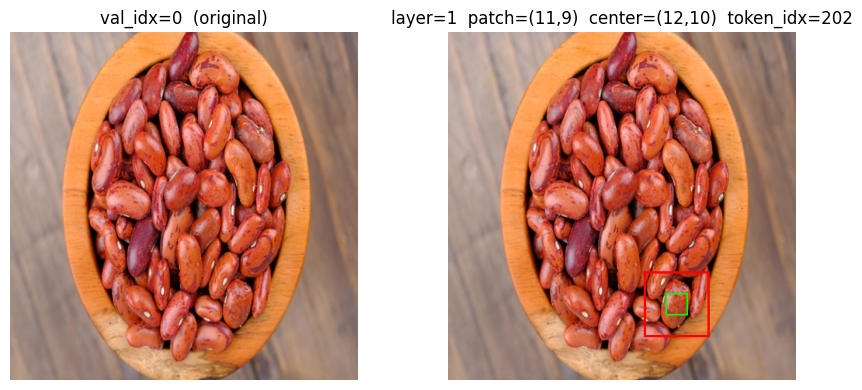

val_idx        : 0
layer          : 1
patch_row/col  : (11, 9)
center_row/col : (12, 10)
patch_token_idx: 202
bbox px        : (252, 308, 336, 392) on 448x448
hidden_state   : shape=(3584,)  norm=40.445  mean=0.0126


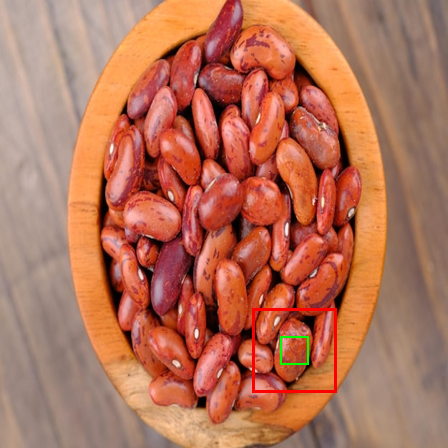

In [4]:
from copy import deepcopy
from PIL import ImageDraw


def _image_by_val_idx(images: datasets.Dataset) -> dict[int, Image.Image]:
    return {int(ex["val_idx"]): ex["image"] for ex in images}


def show_layer_wise_row(
    row,
    images: datasets.Dataset,
    *,
    ds_layer_wise: datasets.Dataset | None = None,
    image_lookup: dict[int, Image.Image] | None = None,
    show_hidden_stats: bool = True,
):
    """Display a layer-wise dataset row with its image and 3x3 patch bbox.

    Args:
        row: Row dict, or integer index into ds_layer_wise.
        images: val100 dataset with embedded PIL images.
        ds_layer_wise: Required if row is an integer index.
        image_lookup: Optional pre-built {val_idx: image} map.
        show_hidden_stats: Print hidden-state norm stats.
    """
    if isinstance(row, int):
        if ds_layer_wise is None:
            raise ValueError("ds_layer_wise is required when row is an index")
        row = ds_layer_wise[row]

    lookup = image_lookup or _image_by_val_idx(images)
    val_idx = int(row["val_idx"])
    if val_idx not in lookup:
        raise KeyError(f"val_idx={val_idx} not found in images dataset")

    img = lookup[val_idx].resize((FIXED_RESOLUTION, FIXED_RESOLUTION)).convert("RGB")
    merged_patch_px = FIXED_RESOLUTION // GRID_SIZE

    patch_row = int(row["patch_row"])
    patch_col = int(row["patch_col"])
    center_row = int(row["center_row"])
    center_col = int(row["center_col"])

    # 3x3 bbox (top-left of sampled position)
    x1 = patch_col * merged_patch_px
    y1 = patch_row * merged_patch_px
    x2 = (patch_col + BBOX_SIZE) * merged_patch_px
    y2 = (patch_row + BBOX_SIZE) * merged_patch_px

    # center merged patch
    cx1 = center_col * merged_patch_px
    cy1 = center_row * merged_patch_px
    cx2 = (center_col + 1) * merged_patch_px
    cy2 = (center_row + 1) * merged_patch_px

    vis = deepcopy(img)
    draw = ImageDraw.Draw(vis)
    draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
    draw.rectangle((cx1, cy1, cx2, cy2), outline="lime", width=2)

    # Make figure a bit smaller
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"val_idx={val_idx}  (original)")
    axes[0].axis("off")

    axes[1].imshow(vis)
    axes[1].set_title(
        f"layer={row['layer']}  patch=({patch_row},{patch_col})  "
        f"center=({center_row},{center_col})  token_idx={row['patch_token_idx']}"
    )
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"val_idx        : {val_idx}")
    print(f"layer          : {row['layer']}")
    print(f"patch_row/col  : ({patch_row}, {patch_col})")
    print(f"center_row/col : ({center_row}, {center_col})")
    print(f"patch_token_idx: {row['patch_token_idx']}")
    print(f"bbox px        : ({x1}, {y1}, {x2}, {y2}) on {FIXED_RESOLUTION}x{FIXED_RESOLUTION}")

    if show_hidden_stats:
        hs = np.asarray(row["hidden_state"], dtype=np.float32)
        print(f"hidden_state   : shape={hs.shape}  norm={np.linalg.norm(hs):.3f}  mean={hs.mean():.4f}")

    return vis


# Example: show row 0
show_layer_wise_row(0, data, ds_layer_wise=ds_layer_wise)


In [5]:
# for each sample, find top 5 words and record metadata and hypernym metrics

import sys
from typing import Optional

import spacy
from nltk.corpus import wordnet as wn

_QLLENS_SRC = Path("/workspace/latentlens/experiment/qllens/src")
if str(_QLLENS_SRC) not in sys.path:
    sys.path.insert(0, str(_QLLENS_SRC))
from nn_search import search as _nn_search

_spacy_nlp = spacy.load("en_core_web_sm")

# Hidden states are already extracted — free the model to make room for bank embeddings
del model, processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Model freed.")

TOP_K = 5
_NN_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"NN search device: {_NN_DEVICE}")


def _expand_to_word(token_str: str, caption: str, position: int) -> str:
    """Expand a BPE subword to its full surface word using caption + token position."""
    token_clean = token_str.strip().lower()
    if not token_clean:
        return ""

    caption_lower = caption.lower()

    # Prefer match at recorded position (small offset for tokenizer quirks)
    idx = -1
    for offset in range(-2, 3):
        pos = position + offset
        if 0 <= pos <= len(caption_lower) - len(token_clean):
            if caption_lower[pos : pos + len(token_clean)] == token_clean:
                idx = pos
                break

    # Fallback: search in a window around position
    if idx == -1:
        lo = max(0, position - 10)
        hi = min(len(caption_lower), position + len(token_clean) + 10)
        rel = caption_lower[lo:hi].find(token_clean)
        if rel != -1:
            idx = lo + rel

    # Last resort: first occurrence in caption
    if idx == -1:
        idx = caption_lower.find(token_clean)
    if idx == -1:
        return token_clean

    start = idx
    while start > 0 and caption_lower[start - 1].isalpha():
        start -= 1
    end = idx + len(token_clean)
    while end < len(caption_lower) and caption_lower[end].isalpha():
        end += 1

    return caption_lower[start:end]


def _is_noun(word: str) -> bool:
    if not word:
        return False
    doc = _spacy_nlp(word)
    return any(tok.pos_ in ("NOUN", "PROPN") for tok in doc)


def _word_depths(word: str) -> tuple[Optional[int], Optional[int]]:
    """Return min_depth and max_depth from the first WordNet noun synset."""
    synsets = wn.synsets(word, pos=wn.NOUN)
    if not synsets:
        return None, None
    synset = synsets[0]
    return synset.min_depth(), synset.max_depth()


def _neighbor_to_result(n) -> dict:
    full_word = _expand_to_word(n.token_str, n.caption, n.position)
    is_noun = _is_noun(full_word)
    min_depth, max_depth = _word_depths(full_word) if is_noun else (None, None)
    return {
        "word":       n.token_str,
        "full_word":  full_word,
        "position":   n.position,
        "nn_layer":   n.contextual_layer,
        "similarity": round(n.similarity, 4),
        "caption":    n.caption,
        "is_noun":    is_noun,
        "min_depth":  min_depth,
        "max_depth":  max_depth,
    }


def get_nn_results(
    ds_layer_wise: datasets.Dataset,
    banks: dict,
    top_k: int = TOP_K,
) -> list[dict]:
    """Top-k NN search across all reference banks for every row in ds_layer_wise.

    Returns list[dict] with keys: val_idx, layer, top5_results.
    Each entry in top5_results is a dict with word, full_word, position, nn_layer,
    similarity, caption, is_noun, min_depth, max_depth.
    """
    results = []
    for row in tqdm(ds_layer_wise, desc="NN search"):
        hs = torch.tensor(np.asarray(row["hidden_state"], dtype=np.float32))
        neighbors = _nn_search(hs, banks, top_k=top_k, device=_NN_DEVICE)
        results.append({
            "val_idx":      int(row["val_idx"]),
            "layer":        int(row["layer"]),
            "top5_results": [_neighbor_to_result(n) for n in neighbors],
        })
    return results


nn_results = get_nn_results(ds_layer_wise, banks)
print(f"nn_results: {len(nn_results)} rows")
r = nn_results[0]
print(f"val_idx={r['val_idx']}  layer={r['layer']}")
for i, n in enumerate(r["top5_results"], 1):
    print(
        f"  {i}  {n['word']!r} -> {n['full_word']!r}  pos={n['position']}  "
        f"nn_layer={n['nn_layer']}  sim={n['similarity']}"
    )

Model freed.
NN search device: cuda


NN search: 100%|██████████| 800/800 [35:03<00:00,  2.63s/it]

nn_results: 800 rows
val_idx=0  layer=1
  1  ' brown' -> 'brown'  pos=8  nn_layer=2  sim=0.2425
  2  ' brown' -> 'brown'  pos=8  nn_layer=1  sim=0.2386
  3  ' brown' -> 'brown'  pos=4  nn_layer=1  sim=0.2324
  4  ' brown' -> 'brown'  pos=2  nn_layer=1  sim=0.2323
  5  ' matte' -> 'matte'  pos=2  nn_layer=1  sim=0.2306


In [6]:
results_dir = Path("/workspace/latentlens/experiment/data/results")
results_dir.mkdir(parents=True, exist_ok=True)
out_path = results_dir / "nn_results_nf4.json"
with open(out_path, "w") as f:
    json.dump(nn_results, f)
print(f"Saved {len(nn_results)} rows → {out_path}")


Saved 800 rows → /workspace/latentlens/experiment/data/results/nn_results_nf4.json


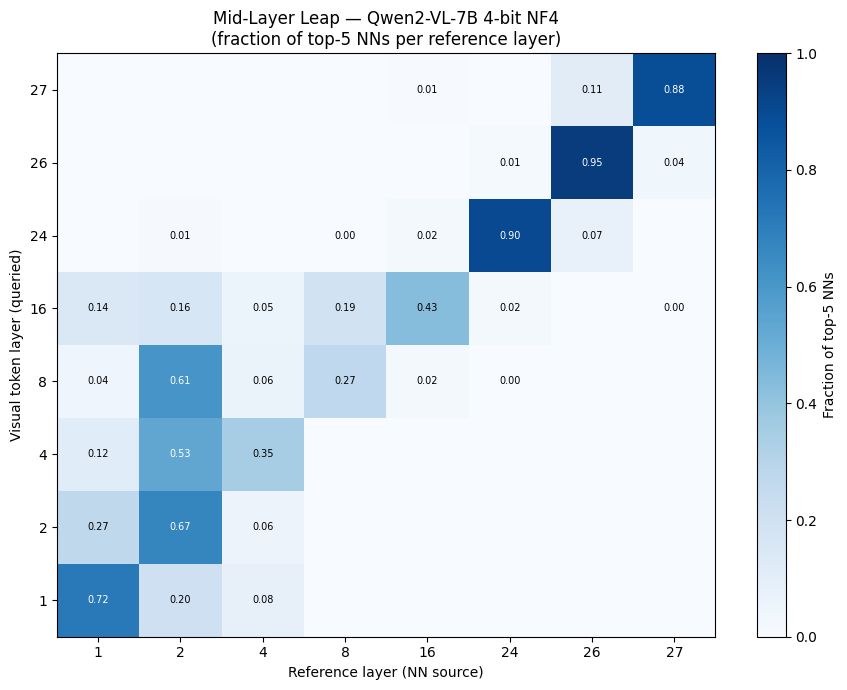

Saved → /workspace/latentlens/experiment/data/results/mid_layer_leap_nf4.png


In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path


# Load results (works after a kernel restart too)
_results_path = Path("/workspace/latentlens/experiment/data/results/nn_results_nf4.json")
with open(_results_path) as f:
    nn_results = json.load(f)

# ── Build mid-layer leap matrix ──────────────────────────────────────────────
# Rows = visual token layer (queried), Cols = reference bank layer (NN source)
# Cell value = mean fraction of top-5 NNs drawn from that reference layer,
#              averaged over all samples with the same visual layer.

queried_layers = sorted({r["layer"] for r in nn_results})
ref_layers     = sorted({n["nn_layer"] for r in nn_results for n in r["top5_results"]})
all_layers     = sorted(set(queried_layers) | set(ref_layers))  # same sequence for both axes

# accumulate fractions per (visual_layer, ref_layer)
counts: dict[tuple, list] = defaultdict(list)
for r in nn_results:
    top5 = [n["nn_layer"] for n in r["top5_results"]]
    vl   = r["layer"]
    for rl in ref_layers:
        counts[(vl, rl)].append(top5.count(rl) / len(top5))

# build square matrix over all_layers; rows not in queried_layers stay 0
matrix = np.zeros((len(all_layers), len(all_layers)))
for i, vl in enumerate(all_layers):
    if vl not in queried_layers:
        continue
    for j, rl in enumerate(all_layers):
        vals = counts.get((vl, rl), [])
        matrix[i, j] = np.mean(vals) if vals else 0.0

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1, origin="lower")
fig.colorbar(im, ax=ax, label="Fraction of top-5 NNs")

ax.set_xticks(range(len(all_layers)))
ax.set_xticklabels(all_layers)
ax.set_yticks(range(len(all_layers)))
ax.set_yticklabels(all_layers)

ax.set_xlabel("Reference layer (NN source)")
ax.set_ylabel("Visual token layer (queried)")
ax.set_title("Mid-Layer Leap — Qwen2-VL-7B 4-bit NF4\n(fraction of top-5 NNs per reference layer)")

# annotate cells with values (skip unqueried rows)
for i, vl in enumerate(all_layers):
    for j, rl in enumerate(all_layers):
        v = matrix[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if v > 0.5 else "black")

plt.tight_layout()
fig_path = Path("/workspace/latentlens/experiment/data/results/mid_layer_leap_nf4.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved → {fig_path}")
